#Principal Component Analysis (PCA)

##Theoretical stuff




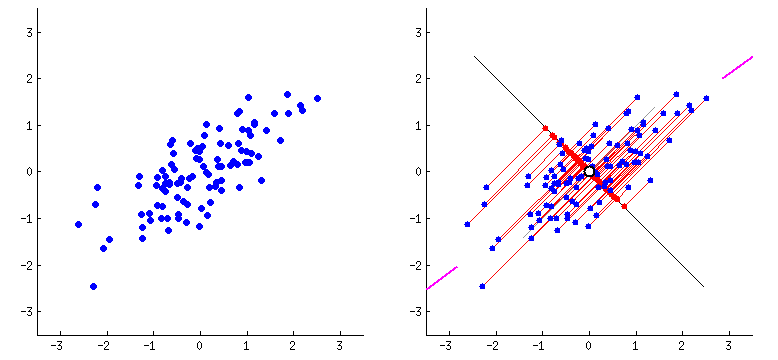

1.Principal Component Analysis (PCA) introduction
Many Machine Learning problems involve thousands or even millions of features for each training instance. Not only does this make training extremely slow, it can also make it much harder to find a good solution. This problem is often referred to as the curse of dimensionality.

Fortunately, in real-world problems, it is often possible to reduce the number of features. Apart from speeding up training, dimensionality reduction is also extremely useful for data visualization.

In most real-world problems, training instances are not spread out uniformly across all dimensions. Many features are almost constant, while others are highly correlated . As a result, all training instances actually lie within (or close to) a much lower-dimensional subspace of the high-dimensional space.



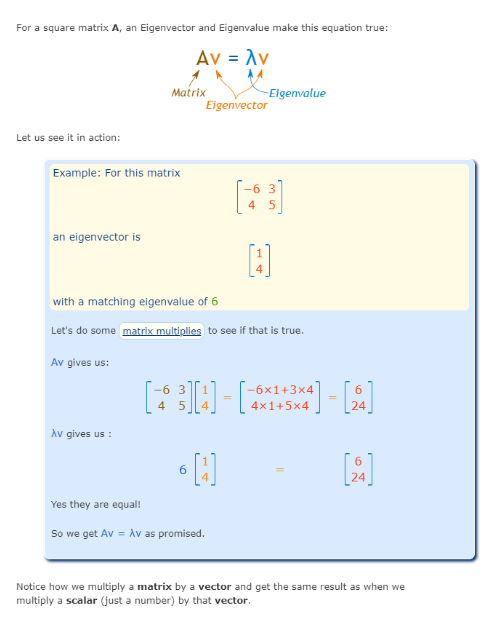



YOU CAN SEE MY ENTIRE PERSONAL NOTES HEREEEEE

https://drive.google.com/drive/u/0/my-drive

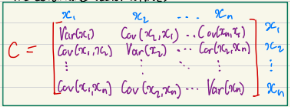



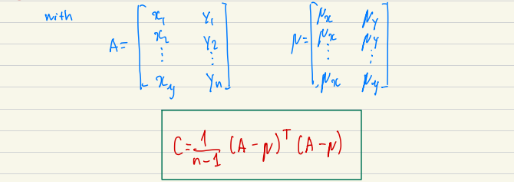

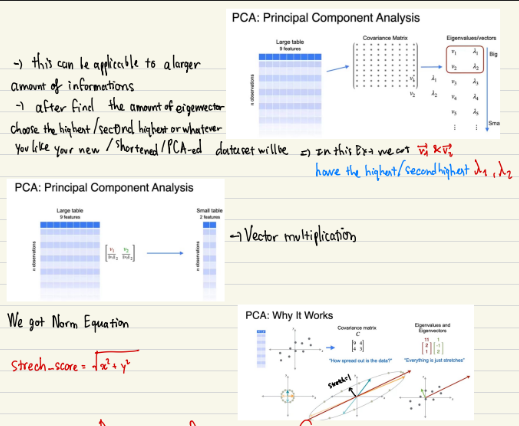

##Coding Integration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

iris_df = sns.load_dataset('iris')
iris_df.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X = np.array(iris_df.iloc[:, :4])
y = iris_df["species"]

X = StandardScaler().fit_transform(X)

###PCA Integration - Compression/Dimensionality Reduction

In [ ]:
from sklearn.decomposition import PCA
'''
In machine learning, decomposition refers to breaking down a complex problem,
data, or model into simpler, more manageable parts. This process can improve
understanding, facilitate computation, or enable specific techniques like
dimensionality reduction or feature extraction.

it involves breaking down a matrix into its constituent parts to gain a deeper
understanding and extract meaningful information from the data it represents.
'''

pca = PCA(n_components=2)

'''
just as i discussed before, PCA is basically methods of reducing the higher
dimensionality matrix/datasets into a smaller dimensionality dataset. And the
parameter of n_components=2 mean that, after the finding of the co
'''

principalComponents = pca.fit_transform(X)
principalDf = pd.DataFrame(data = principalComponents
                           ,columns = ['principal component 1', 'principal component 2'])
final_df = pd.concat([principalDf, iris_df["species"]], axis = 1)

final_df

,principal component 1,principal component 2,species
0,-2.264703,0.480027,setosa
1,-2.080961,-0.674134,setosa
2,-2.364229,-0.341908,setosa
3,-2.299384,-0.597395,setosa
4,-2.389842,0.646835,setosa
...,...,...,...
145,1.870503,0.386966,virginica
146,1.564580,-0.896687,virginica
147,1.521170,0.269069,virginica
148,1.372788,1.011254,virginica


<Axes: xlabel='petal_length', ylabel='petal_width'>

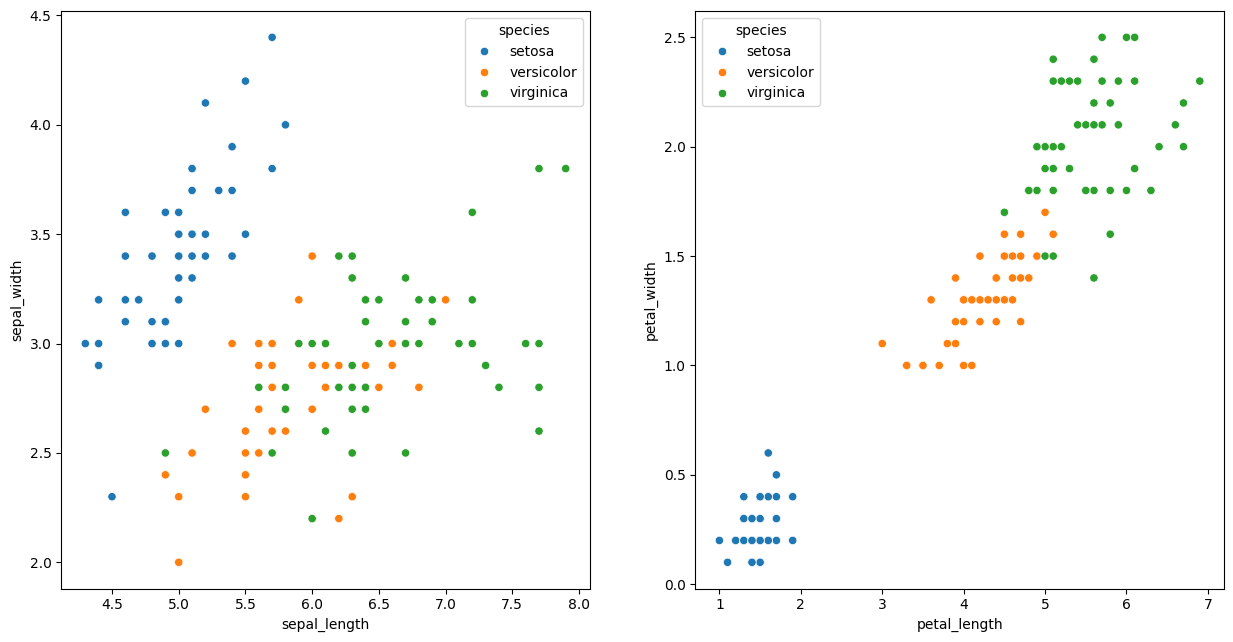

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5) )  # 1 row, 2 columns

sns.scatterplot(data=iris_df, x='sepal_length', y='sepal_width', hue='species', ax=ax[0])
sns.scatterplot(data=iris_df, x='petal_length', y='petal_width', hue='species', ax=ax[1])


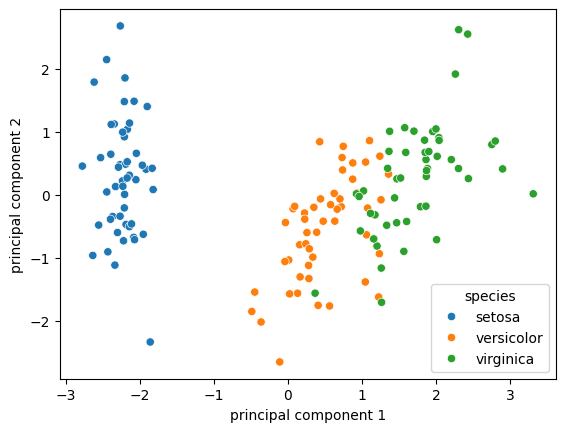

In [ ]:
sns.scatterplot(data=final_df, x='principal component 1', y='principal component 2', hue='species')
plt.show()

In [ ]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

In [ ]:
pca2 = PCA(n_components=0.95)
principalComponents2 = pca2.fit_transform(X)
X_recovered = pca2.inverse_transform(principalComponents2)
X_recovered[:5]

array([[-0.99888895,  1.05319838, -1.30270654, -1.24709825],
       [-1.33874781, -0.06192302, -1.22432772, -1.22057235],
       [-1.36096129,  0.32111685, -1.38060338, -1.35833824],
       [-1.42359795,  0.0677615 , -1.34922386, -1.33881298],
       [-1.00113823,  1.24091818, -1.37125365, -1.30661752]])

In [ ]:
(X_recovered - X)[:5]

array([[-0.09820778,  0.03419403,  0.03751998,  0.06834605],
       [-0.19573089,  0.07005646,  0.11589881,  0.09487195],
       [ 0.02439137, -0.0072972 ,  0.01646057, -0.04289394],
       [ 0.08292257, -0.03045578, -0.06583476, -0.02336868],
       [ 0.02071081, -0.00828294, -0.03102712,  0.00882677]])

In [ ]:
np.mean((X_recovered - X))

np.float64(-3.9968028886505634e-17)

###PCA Integration - Feature Scaling/Range Standardization

Just a standardization preprocessing technique using PCA, though PCA itself is already a preprocessor, but a dimensionality one

[['setosa']
 ['setosa']
 ['versicolor']
 ['setosa']
 ['setosa']]
22        setosa
15        setosa
65    versicolor
11        setosa
42        setosa
Name: species, dtype: object
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        40
  versicolor       0.90      0.85      0.88        41
   virginica       0.85      0.90      0.88        39

    accuracy                           0.92       120
   macro avg       0.92      0.92      0.92       120
weighted avg       0.92      0.92      0.92       120

[[40  0  0]
 [ 0 35  6]
 [ 0  4 35]]


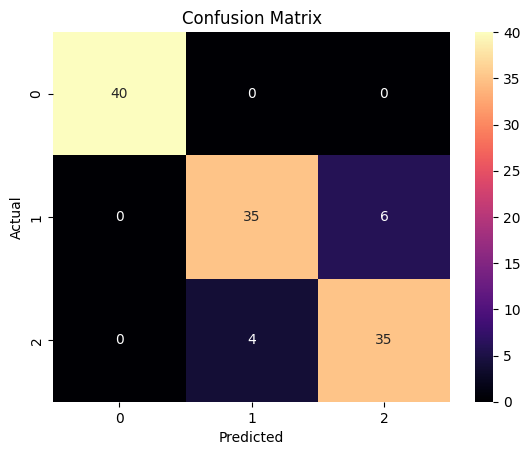

_________________________________________________________________________________________________________________________________________________________
[['versicolor']
 ['setosa']
 ['virginica']
 ['versicolor']
 ['virginica']]
73     versicolor
18         setosa
118     virginica
78     versicolor
76     versicolor
Name: species, dtype: object
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.78      0.88         9
   virginica       0.85      1.00      0.92        11

    accuracy                           0.93        30
   macro avg       0.95      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

[[10  0  0]
 [ 0  7  2]
 [ 0  0 11]]


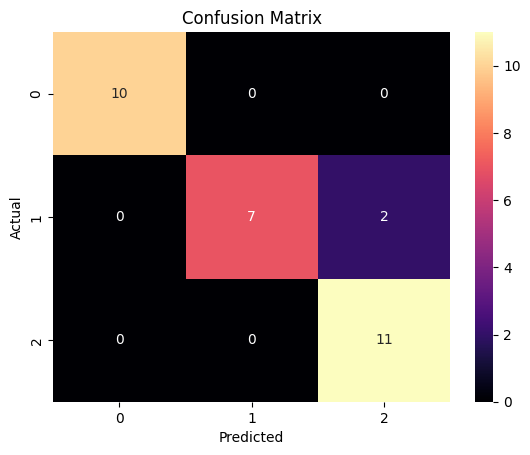

_________________________________________________________________________________________________________________________________________________________


In [ ]:
'''
i will try to use pipeline here bcz i feel like i know how it works but i have
not used them for a while

and inside the pipeline will have a standard scaler and PCA
'''

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

iris_df = sns.load_dataset('iris')
x = np.array(iris_df.iloc[:, :4])
y = iris_df["species"]

PCA_pipeline_model_1 = make_pipeline(StandardScaler(),
                                     PCA(n_components =0.95),
                                     LogisticRegression(random_state=0))
'''
By setting n_components smaller than 1, it describes the percentage of
explained variance that needs to be covered at least. Or in other words, by
setting n_components=0.95 , the number of components are extracted
that cover at least 95% of the explained variance.
'''

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
PCA_pipeline_model_1.fit(x_train, y_train)
y_train_PCA_pipeline_prediction = PCA_pipeline_model_1.predict(x_train)

PCA_pipeline_model_1.fit(x_test, y_test)
y_test_PCA_pipeline_prediction = PCA_pipeline_model_1.predict(x_test)

def result(y_train,y_PCA_pipeline_prediction):
  visualizing_compatibility = confusion_matrix(y_train, y_PCA_pipeline_prediction)
  sns.heatmap(visualizing_compatibility, annot = True, fmt = 'd',cmap="magma", cbar = True)
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title("Confusion Matrix")

  print(y_PCA_pipeline_prediction[:5].reshape(-1,1))
  print(y_train[:5])
  print(classification_report(y_train, y_PCA_pipeline_prediction))
  print(visualizing_compatibility)
  plt.show()
  print("_________________________________________________________________________________________________________________________________________________________")
result(y_train,y_train_PCA_pipeline_prediction)
result(y_test,y_test_PCA_pipeline_prediction)